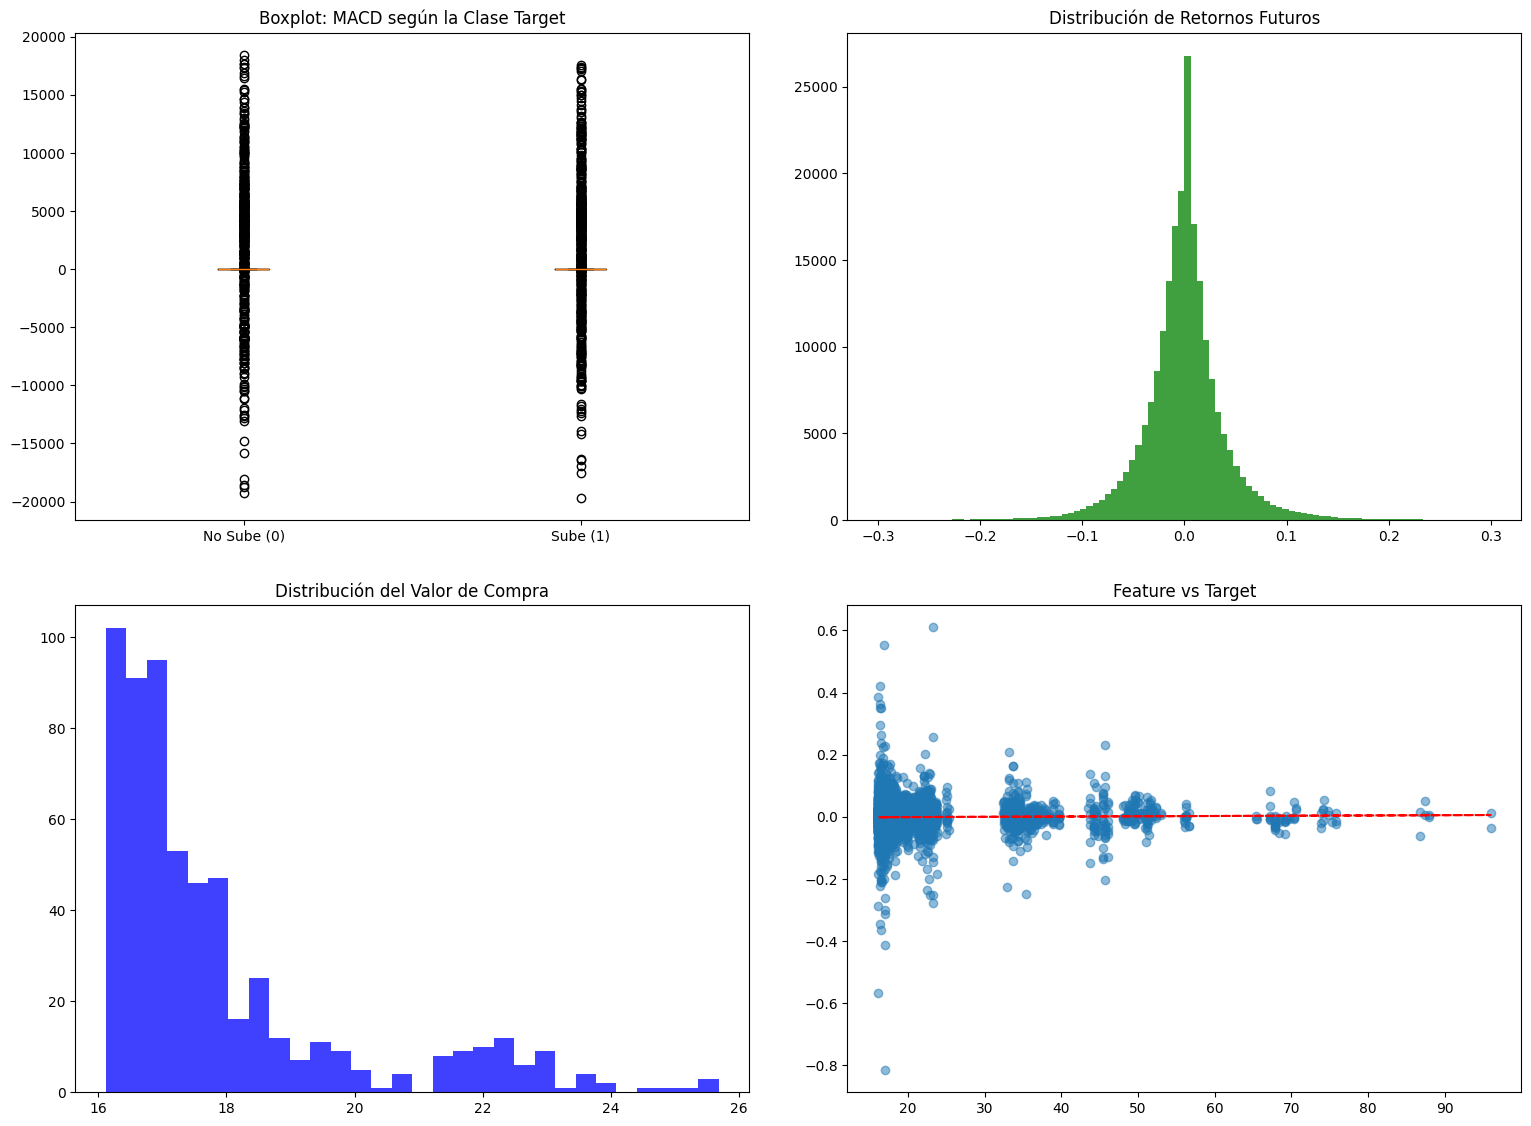

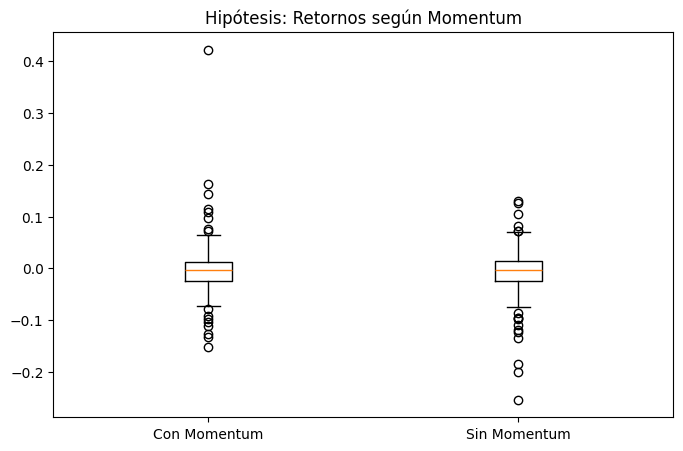

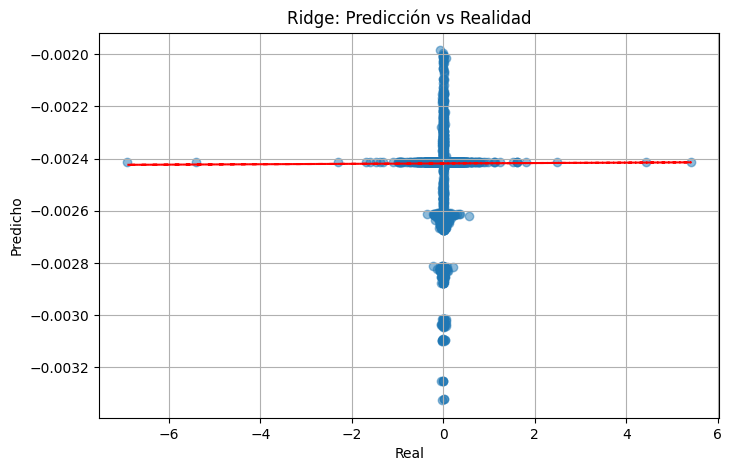

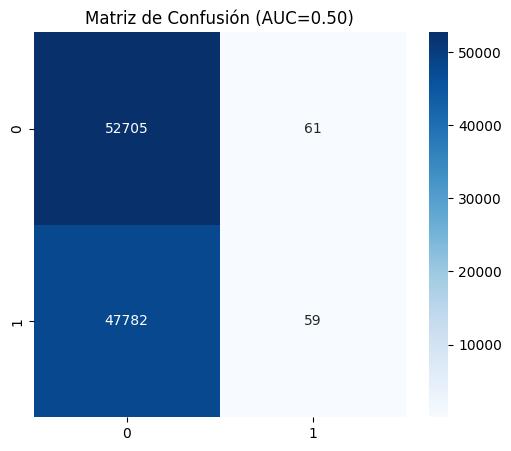

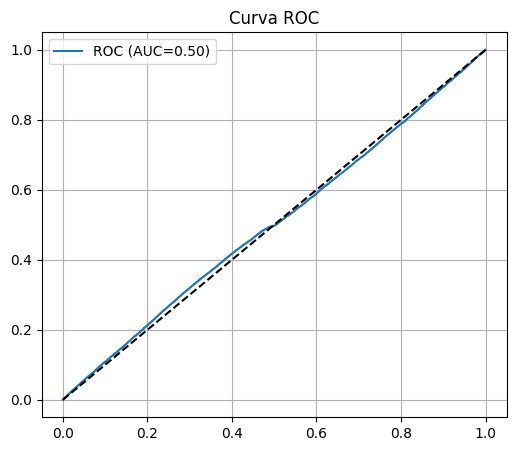

Retorno Estrategia: 1.19%
Retorno Benchmark: 271.46%
Total Operaciones Cerradas: 213


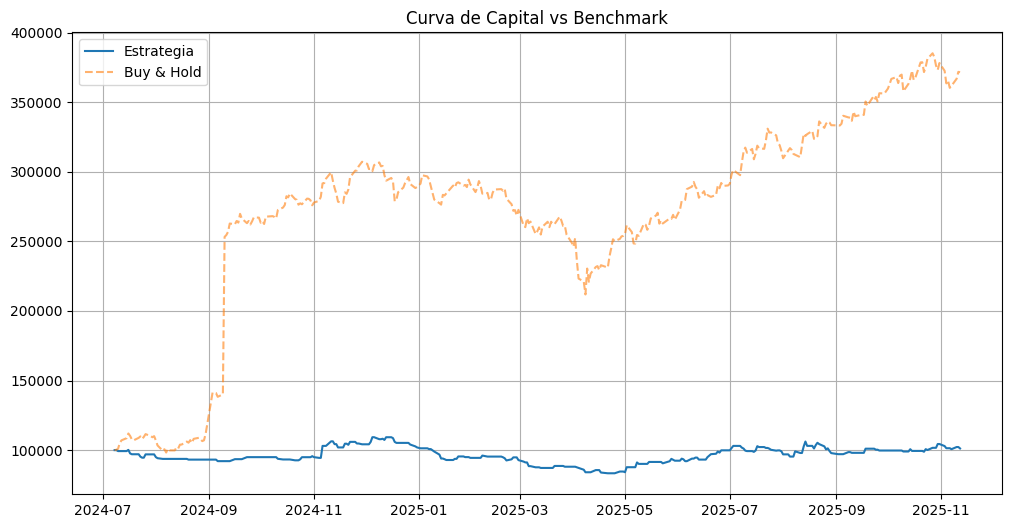

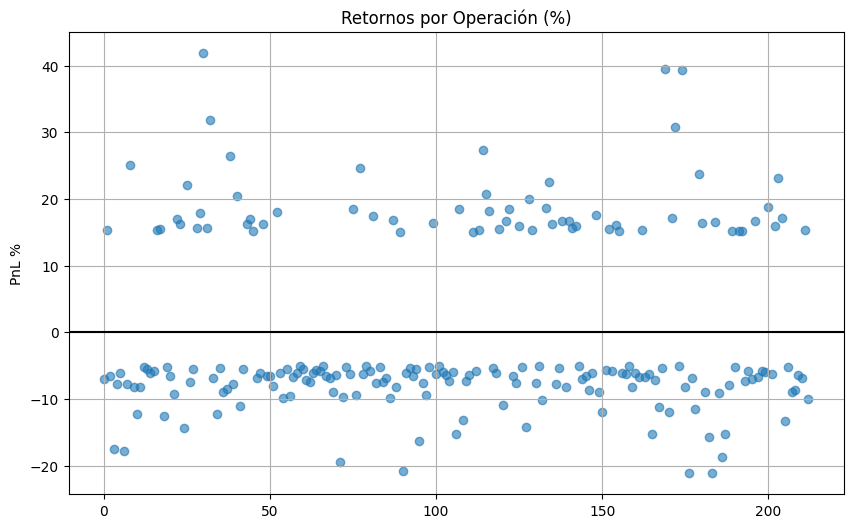

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime, timedelta
from scipy import stats
import warnings
import logging

logging.getLogger('yfinance').setLevel(logging.CRITICAL)
warnings.filterwarnings('ignore')

TRANSACTION_COST = 0.001
SHIFT = 5
MACD_FAST = 12
MACD_SLOW = 26
CV_FOLDS = 3
TRAIN_SIZE = 0.70 
MIN_DATA_DAYS = 100
INITIAL_CAPITAL = 100000

POSITION_SIZE_PCT = 0.10 
RISK = 0.05   
REWARD = 0.15 
SLIPPAGE = 0.0005
MAX_CONCURRENT_POSITIONS = 10
SIGNAL_THRESHOLD = 0.0 

def load_insider_data(csv_file='insider_purchases.csv'):
    try:
        insider_df = pd.read_csv(csv_file, skipinitialspace=True)
        insider_df.columns = [col.replace('\xa0', ' ').replace('  ', ' ').strip() for col in insider_df.columns]
        
        trade_date_col = 'Trade Date'
        filing_date_col = 'Filing Date'
        if trade_date_col not in insider_df.columns or filing_date_col not in insider_df.columns:
            raise KeyError("Columnas requeridas no encontradas.")
            
        insider_df['Filing_Date'] = pd.to_datetime(insider_df[filing_date_col]).dt.date
        
        trade_type_col = 'Trade Type'
        insider_df = insider_df[insider_df[trade_type_col] == 'P - Purchase'].copy()
        
        if insider_df.empty:
            return pd.DataFrame(), pd.DataFrame()

        value_col = 'Value'
        insider_df['Purchase_Value'] = insider_df[value_col].astype(str).str.replace(r'[\+$,]', '', regex=True)
        insider_df = insider_df[insider_df['Purchase_Value'] != '']
        insider_df['Purchase_Value'] = insider_df['Purchase_Value'].astype(float)
        
        ticker_col = 'Ticker'
        daily_signals = insider_df.groupby([ticker_col, 'Filing_Date']).agg({'Purchase_Value': 'sum'}).reset_index()

        insider_df.to_csv('01_insiders_raw.csv', index=False)
        daily_signals.to_csv('02_daily_signals.csv', index=False)

        return insider_df, daily_signals
        
    except Exception:
        return pd.DataFrame(), pd.DataFrame()

def download_ohlc_data(insider_df):
    if insider_df.empty: return pd.DataFrame()
    
    tickers = insider_df['Ticker'].unique()
    
    all_data = []
    for ticker in tickers:
        try:
            yf_ticker = ticker.replace('.', '-')
            start_date = (insider_df[insider_df['Ticker'] == ticker]['Filing_Date'].min() - timedelta(days=365)).strftime('%Y-%m-%d')
            end_date = datetime.now().strftime('%Y-%m-%d')
            
            data = yf.download(yf_ticker, start=start_date, end=end_date, progress=False)
            
            if isinstance(data.columns, pd.MultiIndex):
                data.columns = data.columns.get_level_values(0)

            if not data.empty and len(data) >= MIN_DATA_DAYS:
                data = data.reset_index()
                data['Ticker'] = ticker 
                data = data[['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Ticker']]
                all_data.append(data)
        except Exception:
            pass
    
    if not all_data: return pd.DataFrame()
    
    final_df = pd.concat(all_data, ignore_index=True)
    final_df.to_csv('03_market_prices.csv', index=False)
    return final_df

def add_technical_indicators(df, daily_signals):
    if df.empty or daily_signals.empty: return pd.DataFrame()
    
    df['Date_only'] = pd.to_datetime(df['Date']).dt.date
    df = df.merge(daily_signals, left_on=['Ticker', 'Date_only'], right_on=['Ticker', 'Filing_Date'], how='left')
    
    df['Purchase_Value'] = df['Purchase_Value'].fillna(0)
    df['Log_Purchase_Value'] = np.log1p(df['Purchase_Value'])
    
    df['Rolling_10D_Log_Value'] = df.groupby('Ticker')['Log_Purchase_Value'].transform(
        lambda x: x.rolling(window=10, min_periods=1).sum()
    )

    df.drop(['Date_only', 'Filing_Date', 'Purchase_Value'], axis=1, inplace=True, errors='ignore')

    for ticker in df['Ticker'].unique():
        mask = df['Ticker'] == ticker
        prices = df.loc[mask, 'Close']
        ema12 = prices.ewm(span=MACD_FAST, adjust=False).mean()
        ema26 = prices.ewm(span=MACD_SLOW, adjust=False).mean()
        df.loc[mask, 'MACD'] = ema12 - ema26
        df.loc[mask, 'MACD'] = df.loc[mask, 'MACD'].shift(1)

    df.dropna(subset=['MACD'], inplace=True)
    df.to_csv('04_features_dataset.csv', index=False)
    return df.dropna()

def create_targets_and_split(df):
    if df.empty: return pd.DataFrame()
    
    df = df.sort_values(by=['Ticker', 'Date']).reset_index(drop=True)
    df['Log_Return'] = np.log(df.groupby('Ticker')['Close'].transform(lambda x: x / x.shift(1)))
    df['Future_Log_Return'] = df.groupby('Ticker')['Log_Return'].shift(-SHIFT)
    df[f'{SHIFT} Period Log Return'] = df['Future_Log_Return'] - TRANSACTION_COST * 2
    df['Target_Logistic'] = (df['Future_Log_Return'] > 0).astype(int)
    
    final_df = df.dropna(subset=[f'{SHIFT} Period Log Return', 'Target_Logistic'])
    final_df.to_csv('05_final_model_target.csv', index=False)
    return final_df

def generate_reporting_artifacts(df):
    analysis_df = df.copy()

    tickers_with_signals = df[df['Rolling_10D_Log_Value'] > 0]['Ticker'].unique()
    if len(tickers_with_signals) > 0:
        ticker_stats = df[df['Ticker'].isin(tickers_with_signals)].groupby('Ticker')['Future_Log_Return'].mean()
        top_10 = ticker_stats.sort_values(ascending=False).head(10)
        top_10.to_csv('report_top_tickers.csv')

    signals_df = df[df['Rolling_10D_Log_Value'] > 0].copy()
    if not signals_df.empty:
        try:
            signals_df['Signal_Strength'] = pd.qcut(signals_df['Rolling_10D_Log_Value'], q=3, labels=['Baja', 'Media', 'Alta'])
            quality_table = signals_df.groupby('Signal_Strength')['Future_Log_Return'].agg(['count', 'mean', 'std'])
            quality_table.to_csv('report_signal_quality.csv')
        except Exception:
             pass

    df['Momentum'] = np.where(df['MACD'] > 0, 'Alcista', 'Bajista')
    momentum_table = df.groupby('Momentum')['Future_Log_Return'].agg(['count', 'mean'])
    momentum_table.to_csv('report_momentum.csv')

    df['Year'] = pd.to_datetime(df['Date']).dt.year
    temporal_table = df[df['Rolling_10D_Log_Value'] > 0].groupby('Year')['Future_Log_Return'].agg(['count', 'mean'])
    temporal_table.to_csv('report_yearly_activity.csv')

def manual_ttest(group1, group2):
    n1, n2 = len(group1), len(group2)
    mean1, mean2 = np.mean(group1), np.mean(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_var = ((n1-1)*var1 + (n2-1)*var2) / (n1 + n2 - 2)
    t_stat = (mean1 - mean2) / np.sqrt(pooled_var * (1/n1 + 1/n2))
    df = n1 + n2 - 2
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df))
    return t_stat, p_value

def test_hypothesis(df):
    buys = df[df['Log_Purchase_Value'] > 0].copy()
    if buys.empty: return
    
    g1 = buys[buys['MACD'] > 0]['Future_Log_Return'].dropna().values
    g2 = buys[buys['MACD'] <= 0]['Future_Log_Return'].dropna().values
    
    if len(g1) > 1 and len(g2) > 1:
        t, p = manual_ttest(g1, g2)
        
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.boxplot([g1, g2], labels=['Con Momentum', 'Sin Momentum'])
        ax.set_title('Hipótesis: Retornos según Momentum')
        plt.show()

def sigmoid(z): return 1 / (1 + np.exp(-np.clip(z, -250, 250)))
def manual_logistic_fit(X, y, lr=0.01, epochs=1000, l2_lambda=1.0):
    n, p = X.shape
    weights = np.zeros(p)
    for _ in range(epochs):
        pred = sigmoid(np.dot(X, weights))
        grad = (1/n) * np.dot(X.T, (pred - y))
        weights -= lr * (grad + l2_lambda * weights / n)
    return weights
def manual_auc(y_true, y_pred):
    idx = np.argsort(-y_pred)
    tpr = np.cumsum(y_true[idx]) / y_true.sum()
    fpr = np.cumsum(1 - y_true[idx]) / (1 - y_true).sum()
    return np.trapz(tpr, fpr)
def manual_confusion_matrix(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return np.array([[tn, fp], [fn, tp]])

def run_ridge_cv_manual(train, test, features):
    X_train = train[features].values
    y_train = train[f'{SHIFT} Period Log Return'].values
    X_test = test[features].values
    
    mu, sigma = X_train.mean(axis=0), X_train.std(axis=0)
    sigma[sigma==0] = 1
    X_train_s = (X_train - mu) / sigma
    X_test_s = (X_test - mu) / sigma
    
    mu_y, sigma_y = y_train.mean(), y_train.std()
    y_train_s = (y_train - mu_y) / sigma_y
    
    X_b = np.c_[np.ones(len(X_train_s)), X_train_s]
    I = np.eye(X_b.shape[1])
    beta = np.linalg.inv(X_b.T @ X_b + 10.0 * I) @ X_b.T @ y_train_s
    
    X_test_b = np.c_[np.ones(len(X_test_s)), X_test_s]
    preds_s = X_test_b @ beta
    preds = preds_s * sigma_y + mu_y
    
    test['Predicted_Return'] = preds
    
    plt.figure(figsize=(8, 5))
    plt.scatter(test[f'{SHIFT} Period Log Return'], preds, alpha=0.5)
    z = np.polyfit(test[f'{SHIFT} Period Log Return'], preds, 1)
    plt.plot(test[f'{SHIFT} Period Log Return'], np.poly1d(z)(test[f'{SHIFT} Period Log Return']), "r--")
    plt.title('Ridge: Predicción vs Realidad')
    plt.xlabel('Real')
    plt.ylabel('Predicho')
    plt.grid(True)
    plt.show()
    
    return beta, {'mean_x': mu, 'std_x': sigma, 'mean_y': mu_y, 'std_y': sigma_y}

def run_logistic_cv_manual(train, test, features):
    target = 'Target_Logistic'
    X_train = train[features].values
    y_train = train[target].values
    X_test = test[features].values
    y_test = test[target].values
    
    mu, sigma = X_train.mean(axis=0), X_train.std(axis=0)
    sigma[sigma==0] = 1
    X_train_s = (X_train - mu) / sigma
    X_test_s = (X_test - mu) / sigma
    
    X_train_b = np.c_[np.ones(len(X_train_s)), X_train_s]
    X_test_b = np.c_[np.ones(len(X_test_s)), X_test_s]
    
    weights = manual_logistic_fit(X_train_b, y_train, l2_lambda=1.0)
    probs = sigmoid(np.dot(X_test_b, weights))
    preds = (probs > 0.5).astype(int)
    
    auc = manual_auc(y_test, probs)
    
    try:
        import seaborn as sns
        cm = manual_confusion_matrix(y_test, preds)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Matriz de Confusión (AUC={auc:.2f})')
        plt.show()
    except ImportError:
        pass

    idx = np.argsort(-probs)
    tpr = np.cumsum(y_test[idx]) / y_test.sum()
    fpr = np.cumsum(1 - y_test[idx]) / (1 - y_test).sum()
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'ROC (AUC={auc:.2f})')
    plt.plot([0,1],[0,1],'k--')
    plt.title('Curva ROC')
    plt.legend()
    plt.grid()
    plt.show()

    return weights, None

def run_model_simulation(test_df, ridge_beta, scalers, features):
    X_test = test_df[features].values
    X_test_norm = (X_test - scalers['mean_x']) / scalers['std_x']
    X_test_b = np.c_[np.ones(len(X_test_norm)), X_test_norm]
    preds_norm = X_test_b @ ridge_beta
    test_df['Predicted_Return'] = preds_norm * scalers['std_y'] + scalers['mean_y']
    
    test_df['Signal'] = 0
    for date in test_df['Date'].unique():
        day_mask = test_df['Date'] == date
        day_preds = test_df.loc[day_mask, 'Predicted_Return']
        if not day_preds.empty:
            n_top = min(len(day_preds), 5)
            top_5_idx = day_preds.nlargest(n_top).index
            test_df.loc[top_5_idx, 'Signal'] = 1
            
    test_df['Signal'] = test_df.groupby('Ticker')['Signal'].shift(1).fillna(0)
    
    closes = test_df.pivot(index='Date', columns='Ticker', values='Close')
    mkt_ret = closes.pct_change().mean(axis=1).fillna(0)
    bnh_curve = INITIAL_CAPITAL * (1 + mkt_ret).cumprod()
    bnh_final = (bnh_curve.iloc[-1]/INITIAL_CAPITAL - 1)*100
    
    capital = INITIAL_CAPITAL
    curve = [capital]
    positions = {} 
    trades_log = []
    
    dates = sorted(test_df['Date'].unique())
    for d in dates:
        day_data = test_df[test_df['Date'] == d]
        
        closed_pnl = 0
        for t in list(positions.keys()):
            if t in day_data['Ticker'].values:
                curr = day_data[day_data['Ticker'] == t]['Close'].values[0]
                entry = positions[t]['price']
                ret = (curr / entry) - 1
                
                if ret <= -RISK or ret >= REWARD:
                    pnl = (capital * POSITION_SIZE_PCT) * ret
                    closed_pnl += pnl
                    trades_log.append(ret)
                    del positions[t]
        
        capital += closed_pnl
        
        buys = day_data[day_data['Signal'] == 1]
        for _, row in buys.iterrows():
            if len(positions) < MAX_CONCURRENT_POSITIONS and row['Ticker'] not in positions:
                positions[row['Ticker']] = {'price': row['Close']}
                
        curve.append(capital)
    
    strat_final = (curve[-1]/INITIAL_CAPITAL - 1)*100
    
    print(f"Retorno Estrategia: {strat_final:.2f}%")
    print(f"Retorno Benchmark: {bnh_final:.2f}%")
    print(f"Total Operaciones Cerradas: {len(trades_log)}")

    plt.figure(figsize=(12, 6))
    plt.plot(dates, curve[1:], label='Estrategia')
    plt.plot(dates, bnh_curve.reindex(dates).fillna(method='ffill'), label='Buy & Hold', linestyle='--', alpha=0.6)
    plt.title('Curva de Capital vs Benchmark')
    plt.legend()
    plt.grid()
    plt.show()
    
    if trades_log:
        pd.DataFrame(trades_log, columns=['Return']).to_csv('backtest_trades_log.csv', index=False)
        plt.figure(figsize=(10, 6))
        plt.scatter(range(len(trades_log)), [t*100 for t in trades_log], alpha=0.6)
        plt.axhline(0, color='black')
        plt.title('Retornos por Operación (%)')
        plt.ylabel('PnL %')
        plt.grid()
        plt.show()

def mas_plots(df):
    if df.empty: return

    fig, ax = plt.subplots(2, 2, figsize=(16, 12))
    plt.tight_layout(pad=4.0)

    class0 = df[df['Target_Logistic'] == 0]['MACD'].values
    class1 = df[df['Target_Logistic'] == 1]['MACD'].values
    ax[0, 0].boxplot([class0, class1], labels=['No Sube (0)', 'Sube (1)'])
    ax[0, 0].set_title('Boxplot: MACD según la Clase Target')

    ax[0, 1].hist(df['Future_Log_Return'], bins=100, alpha=0.75, color='green', range=(-0.3, 0.3))
    ax[0, 1].set_title('Distribución de Retornos Futuros')

    active_signals_log = df[df['Log_Purchase_Value'] > 0]['Log_Purchase_Value']
    if not active_signals_log.empty:
        ax[1, 0].hist(active_signals_log, bins=30, alpha=0.75, color='blue')
        ax[1, 0].set_title('Distribución del Valor de Compra')
        
    active = df[df['Rolling_10D_Log_Value'] > 0]
    if not active.empty:
        ax[1, 1].scatter(active['Rolling_10D_Log_Value'], active['Future_Log_Return'], alpha=0.5)
        z = np.polyfit(active['Rolling_10D_Log_Value'], active['Future_Log_Return'], 1)
        ax[1, 1].plot(active['Rolling_10D_Log_Value'], np.poly1d(z)(active['Rolling_10D_Log_Value']), "r--")
        ax[1, 1].set_title('Feature vs Target')
    
    plt.show()

if __name__ == "__main__":
    insider_df, daily_signals = load_insider_data()
    
    if not insider_df.empty:
        ohlc_df = download_ohlc_data(insider_df)
        
        if not ohlc_df.empty:
            features_df = add_technical_indicators(ohlc_df, daily_signals)
            df_final = create_targets_and_split(features_df)
            
            dates = sorted(df_final['Date'].unique())
            split_idx = int(len(dates) * TRAIN_SIZE)
            split_date = dates[split_idx]
            
            train = df_final[df_final['Date'] <= split_date].copy()
            test = df_final[df_final['Date'] > split_date].copy()
            
            features = ['MACD', 'Rolling_10D_Log_Value']
            
            generate_reporting_artifacts(pd.concat([train, test]))
            mas_plots(pd.concat([train, test]))
            test_hypothesis(train)
            
            ridge_beta, scalers = run_ridge_cv_manual(train, test.copy(), features)
            run_logistic_cv_manual(train, test.copy(), features)
            
            run_model_simulation(test.copy(), ridge_beta, scalers, features)